In [1]:
# Source - https://stackoverflow.com/a
# Posted by matthiash, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-09, License - CC BY-SA 3.0

from IPython.display import HTML
HTML('''<script>
code_show_err=false; 
function code_toggle_err() {
 if (code_show_err){
 $('div.output_stderr').hide();
 } else {
 $('div.output_stderr').show();
 }
 code_show_err = !code_show_err
} 
$( document ).ready(code_toggle_err);
</script>
To toggle on/off output_stderr, click <a href="javascript:code_toggle_err()">here</a>.''')

In [2]:
from pathlib import Path
from os import environ


# IN_COLAB = False
# if "DRIVE_HOME" in environ:
  # ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
# else:
ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/binom2d")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/wbic-bias")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data
Using outputdir=/mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/wbic-bias


In [3]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,p0,p1,w0,w1
0,regular,0.15,0.35,0.75,0.25
1,e-singular,0.25,0.35,0.75,0.25
2,singular1,0.15,0.35,1.00,0.00
3,singular2,0.35,0.35,0.75,0.25


In [4]:
from sklearn_extensions.mixbinom import BinomialMixture


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
  return truth

def rlct_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  n_components = np.ceil(len(truth)/2)
  rlct = None
  match dsid:
    case "regular" | "e-singular":
      rlct = (n_components*2-1)/2
    case "singular1" | "singular2":
      rlct = 1
    case _:
      raise Exception(f"Uknown dsid={dsid}")

  return rlct

def approx_free_energy_by_dsid(dsid, n_trials, X):
  n=len(X)
  
  average_log_likelihood = None
  model = BinomialMixture(n_components=2, n_trials=n_trials, enforce_ordering=False)
  input_data = np.column_stack([X, np.full_like(X, n_trials)])
  model.fit(input_data)
  mle, _ = model.point_estimate()
  log_p = mixbinom.logpmf(weights=[mle[2], 1-mle[2]], probs=[mle[0], mle[1]], n=n_trials, x=X) # sample likelihood under the mle
  average_log_likelihood = log_p.mean()

  afe = -n_obs*average_log_likelihood+rlct_by_dsid(dsid)*np.log(n_obs)
  return afe


def expected_free_energy_by_dsid(dsid, n_trials, n):
  X = np.arange(0, n_trials, 1)
  truth = find_truth_by_dsid(dsid)
  weights_0=truth[2:3]
  probs_0=truth[0:1]

  log_q = mixbinom.logpmf(n=n_trials, weights=weights_0, probs=probs_0, x=X)
  log_p = mixbinom.logpmf(n=n_trials, weights=weights_0, probs=probs_0, x=X)
  expected_log_likelihood = np.exp(log_q)*log_p
  second_order_term = rlct_by_dsid(dsid)*np.log(n)

  efe = -n * expected_log_likelihood.sum() + second_order_term
  return efe

In [5]:
# compute AFE and WBIC for many samples, 
# AFE requires sampling with beta=1 while WBIC requires sampling with beta=1/sqrt(n)
# for different n

In [6]:
import pandas as pd
import json
from pathlib import Path

results_file = Path(f"{outputdir}/fe_estimators_results.csv")

# Load existing results if file exists
if results_file.exists():
  fe_estimators_df = pd.read_csv(results_file)
  # Create a set of completed (run, regime, dsid) tuples for fast lookup
  completed = set(
      zip(fe_estimators_df["trial"], fe_estimators_df["regime"], fe_estimators_df["dsid"])
  )
  fe_estimators_data = fe_estimators_df.to_dict("records")
else:
  completed = set()
  fe_estimators_data = []

def save_results():
  """Save current results to disk."""
  pd.DataFrame(fe_estimators_data).to_csv(results_file, index=False)

In [7]:
from pymc_extensions.tempered_mixbinom import TemperedBinomialMixture
from pymc_extensions import pmx
from scipy_extensions import mixbinom
from tqdm.notebook import tqdm
import pymc as pm
import numpy as np
import arviz as az


n_components = 2
n_trials=100
regimes = [50, 250, 5000]

# mcmc settings
n_tune=4000
n_draws=1000
n_chains=4

# read all the data so we can nicely loop 
for run in tqdm(range(1000), desc=f"runs "):
  if run > 20:
    break

  for regime in tqdm(regimes, desc="regimes"):
    for dsid in dgps["dsid"].unique():
      # Skip if already completed
      if (run, regime, dsid) in completed:
          continue

      # try:
      dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")

      X = dataset.iloc[:, run].to_numpy()
      n_obs = len(X)
      efe = expected_free_energy_by_dsid(dsid=dsid, n_trials=n_trials, n=n_obs)
      afe = approx_free_energy_by_dsid(dsid=dsid, n_trials=n_trials, X=X)

      with TemperedBinomialMixture(X=X, n_trials=100, beta=1/np.log(n_obs)) as model:
        idata = model.sample(draws=n_draws, 
                             tune=n_tune, 
                             chains=n_chains, 
                             progressbar=False)  # or "blackjax"

        # Divergences are stored in sample_stats as a boolean array (chain, draw)
        diverging = idata.sample_stats.diverging.values
        
        # Divergences per chain
        divs_per_chain = diverging.sum(axis=1)  # array with one value per chain
        
        # Summary statistics
        mean_divergences = divs_per_chain.mean()
        total_divergences = diverging.sum()
        max_divergences = divs_per_chain.max()
        
        weights = pmx.column_stack_vars(idata, ["weights"])
        probs = pmx.column_stack_vars(idata, ["p0", "p1"])
        log_likelihood = mixbinom.log_likelihood(weights, probs, n=n_trials, x=X)
        wbic = -log_likelihood.mean()
        print(f"wbic={wbic}, afe={afe}, efe={efe}")
        result = {
          "dsid": dsid,
          "regime": regime,
          "n": regime,
          "trial": run,
          "wbic": wbic,
          "afe": afe,
          "efe": efe,
          "chains": n_chains,
          "draws": n_draws,
          "tune": n_tune,
          "mean_divergences": mean_divergences,
          "total_divergences": total_divergences,
          "max_divergences": max_divergences,
          "divergences_per_chain": divs_per_chain.tolist(),
          "chain_tree_depth": idata.sample_stats.tree_depth.values.max()
        }

        fe_estimators_data.append(result)
        completed.add((run, regime, dsid))
        
  # Save after each successful run
  save_results()

runs :   0%|          | 0/1000 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

...

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

In [11]:
fe_estimates_df = pd.DataFrame(fe_estimators_data)
fe_estimates_df.style.format({'wbic': '{:.3f}', 'efe': '{:.3f}'})
fe_estimates_df["trial"].unique()

array([0, 1, 2, 4, 3, 5])

,dsid,regime,n,trial,wbic,efe,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth
0,regular,50,50,3,8518.326,325.993,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",7
1,e-singular,50,50,3,8472.395,221.094,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",7
2,singular1,50,50,3,7200.182,144.447,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",9
3,singular2,50,50,3,7558.620,166.978,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",9
4,regular,250,250,3,208524.695,1693.113,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",7
5,e-singular,250,250,3,200508.913,950.370,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",7
6,singular1,250,250,3,170485.894,682.540,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",10
7,singular2,250,250,3,186967.768,820.964,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",10
8,regular,5000,5000,3,82793676.666,30441.102,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",7
9,e-singular,5000,5000,3,80041641.716,19032.798,4,1000,4000,0.000000,0,0,"[0, 0, 0, 0]",7


In [ ]:
def chain_diag(dsid="singular1", regime=5000):
  az.plot_trace(posterior_samples[dsid][regime], combined=True)

In [ ]:
chain_diag("regular", 5000)

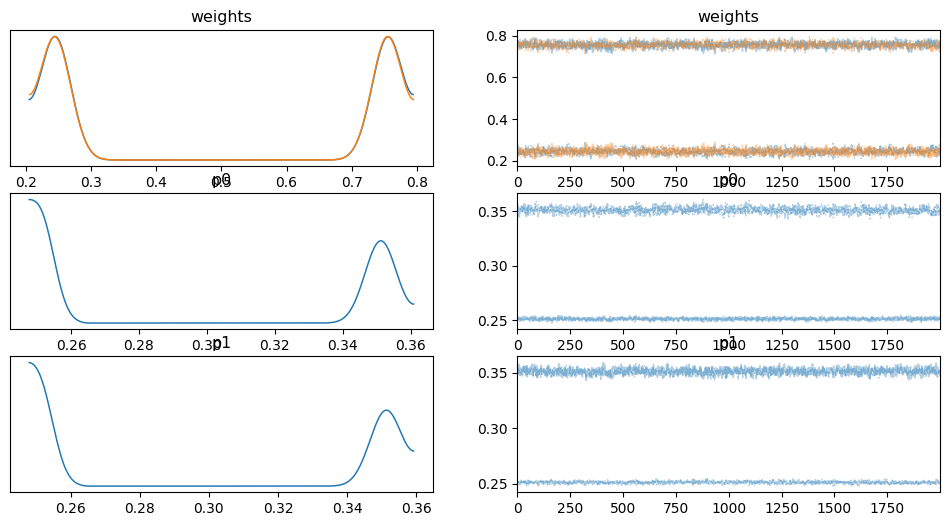

In [8]:
chain_diag("e-singular", 5000)

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot3d(dsid="singular1", regime=5000):
  idata = posterior_samples[dsid][regime]
  w = idata.posterior["weights"][1,:,0]
  p0 = idata.posterior["p0"][1,:]
  p1 = idata.posterior["p1"][1,:]
  
  fig = plt.figure(figsize=(12, 10))  # width, height in inches
  ax = fig.add_subplot(111, projection='3d')
  
  n_chains = idata.posterior.dims["chain"]
  n_draws = idata.posterior.dims["draw"]
  markers = ['o', '^', '.', '+']
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain,:,0]
    p0 = idata.posterior["p0"][chain,:]
    p1 = idata.posterior["p1"][chain,:]
    ax.scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)


/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_55890/508105621.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims["chain"]
/var/folders/jf/4t6y1sj967l2ctl46wj73srh0000gn/T/ipykernel_55890/508105621.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = idata.posterior.dims["draw"]


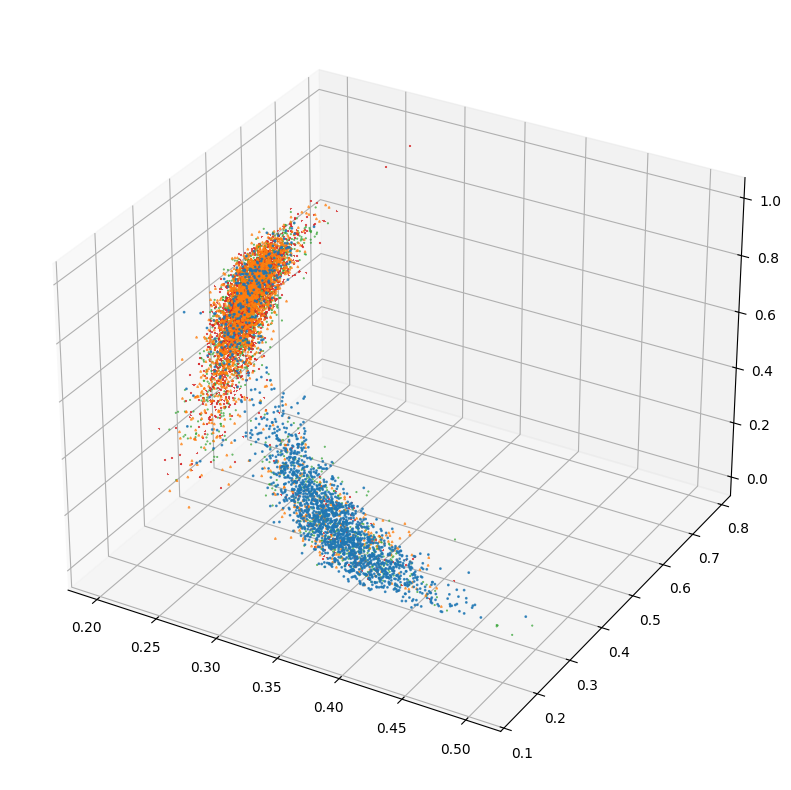

In [13]:
plot3d(dsid="e-singular", regime=50)

In [14]:
import plotly.graph_objects as go
import plotly.io as pio

def plot3dx(dsid="regular", regime=50):
  idata = posterior_samples[dsid][regime]
  fig = go.Figure()
  
  markers = ['circle', 'diamond', 'square', 'cross']
  n_chains = idata.posterior.dims["chain"]
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain, :, 0].values
    p0 = idata.posterior["p0"][chain, :].values
    p1 = idata.posterior["p1"][chain, :].values
    
    fig.add_trace(go.Scatter3d(
        x=p0, y=p1, z=w,
        mode='markers',
        marker=dict(size=1, symbol=markers[chain]),
        name=f'Chain {chain}'
    ))
  
  fig.update_layout(
      scene=dict(
          xaxis_title='p0',
          yaxis_title='p1',
          zaxis_title='w'
      )
  )
  
  # For Jupyter notebooks
  pio.renderers.default = "notebook"
  # or
  # pio.renderers.default = "iframe"
  # or for JupyterLab
  # pio.renderers.default = "jupyterlab"
  fig.update_layout(
      width=1000,
      height=800
  )
  fig.show()